# Bagging-learning-tool


In [231]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
from sklearn.inspection import DecisionBoundaryDisplay
import numpy as np

In [232]:
df = load_iris(as_frame = True).frame
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [233]:
df = df.loc[df.target != 0][['sepal width (cm)','petal length (cm)', 'target']]
df =  df.sample(100)
df

,sepal width (cm),petal length (cm),target
136,3.4,5.6,2
127,3.0,4.9,2
70,3.2,4.8,1
130,2.8,6.1,2
54,2.8,4.6,1
...,...,...,...
120,3.2,5.7,2
122,2.8,6.7,2
88,3.0,4.1,1
113,2.5,5.0,2


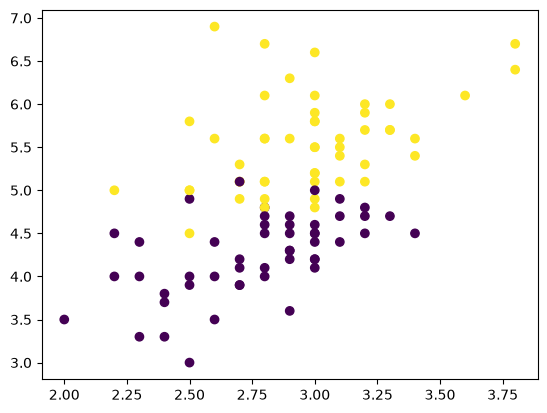

In [234]:
import matplotlib.pyplot as plt
plt.scatter(x = df['sepal width (cm)'], y = df['petal length (cm)'], c = df['target'] )

In [235]:
df_train = df.iloc[:50, :].sample(10)
df_val = df.iloc[50:80, : ].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [236]:
X_test = df_val.iloc[:,0:2]
y_test = df_val.iloc[:,-1]


## Case 1: Bagging

In [237]:
def evaluate(clf, X, y):
    clf = clf
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()

    DecisionBoundaryDisplay.from_estimator
    clf,
    X.values,
    response_method="predict",
    cmap="viridis",
    alpha=0.4,
    plt.scatter(X.iloc[:,0], X.iloc[:,1], c = y, edgecolors= 'k')
    

    y_pred = clf.predict(X_test)
    print(f'{clf} : ', accuracy_score(y_test, y_pred))
    print(f'Training Score: ',clf.score(X, y))
    print('Testing Score: ', clf.score(X_test, y_test))


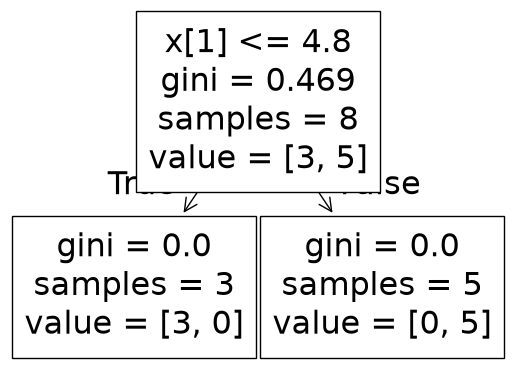

DecisionTreeClassifier(random_state=42) :  1.0
Training Score:  1.0
Testing Score:  1.0


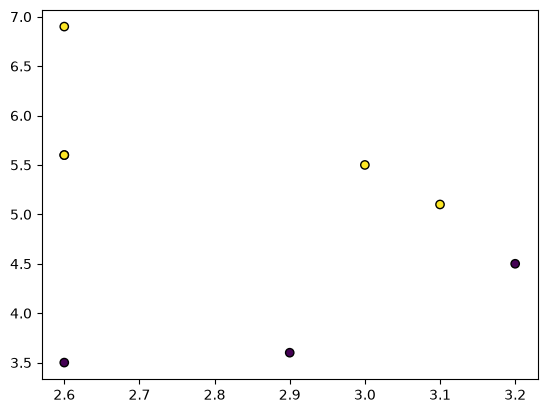

In [238]:
df_bag = df_train.sample(8,replace= True)
dt_bag1 = DecisionTreeClassifier(random_state= 42)
X = df_bag.iloc[:, 0:2]
y = df_bag.iloc[:,-1]
evaluate(dt_bag1, X,y)

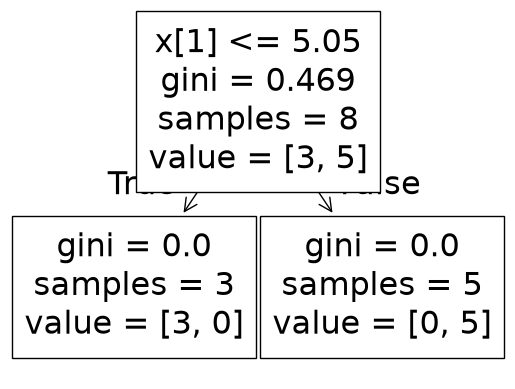

DecisionTreeClassifier() :  0.8
Training Score:  1.0
Testing Score:  0.8


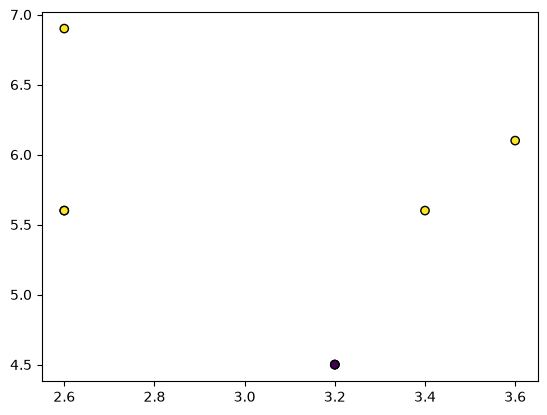

In [239]:
df_bag = df_train.sample(8, replace = True)
dt_bag2 = DecisionTreeClassifier()
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
evaluate(dt_bag2, X,y)

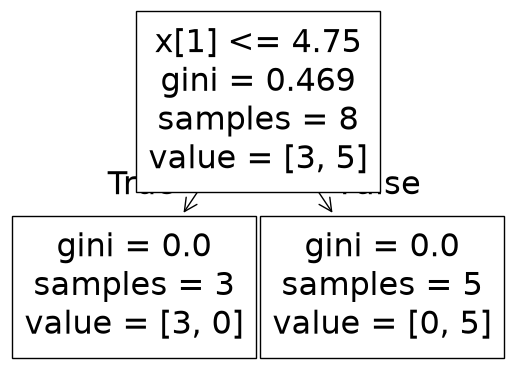

DecisionTreeClassifier() :  1.0
Training Score:  1.0
Testing Score:  1.0


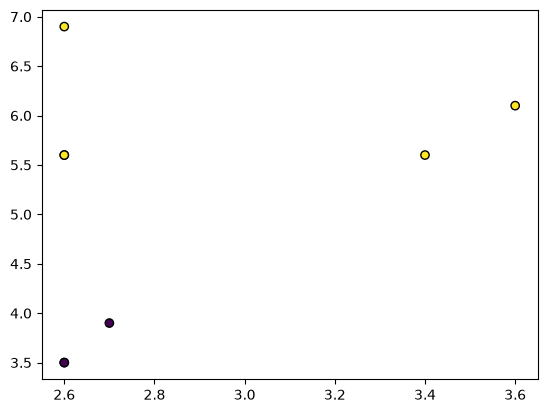

In [240]:
df_bag = df_train.sample(8, replace= True)
dt_bag3 = DecisionTreeClassifier()
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
evaluate(dt_bag3, X,y)

## Predict

In [241]:
df_test

,sepal width (cm),petal length (cm),target
122,2.8,6.7,2
83,2.7,5.1,1
88,3.0,4.1,1
69,2.5,3.9,1
115,3.2,5.3,2


In [242]:
print('Prediction 1 : ',dt_bag1.predict(np.array([2.0, 3.5]).reshape(1,2)))
print('Prediction 2 : ',dt_bag2.predict(np.array([2.0, 3.5]).reshape(1,2)))
print('Prediction 3 : ',dt_bag3.predict(np.array([2.0, 3.5]).reshape(1,2)))


Prediction 1 :  [1]
Prediction 2 :  [1]
Prediction 3 :  [1]


d:\scikit-learn.py\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\scikit-learn.py\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\scikit-learn.py\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## Pasting

In [243]:
df_train

,sepal width (cm),petal length (cm),target
59,2.7,3.9,1
51,3.2,4.5,1
79,2.6,3.5,1
64,2.9,3.6,1
136,3.4,5.6,2
116,3.0,5.5,2
141,3.1,5.1,2
118,2.6,6.9,2
109,3.6,6.1,2
134,2.6,5.6,2


In [244]:
df_train.sample(8)

,sepal width (cm),petal length (cm),target
118,2.6,6.9,2
79,2.6,3.5,1
109,3.6,6.1,2
141,3.1,5.1,2
116,3.0,5.5,2
136,3.4,5.6,2
59,2.7,3.9,1
51,3.2,4.5,1


## Random Subspaces

In [245]:
df_train

,sepal width (cm),petal length (cm),target
59,2.7,3.9,1
51,3.2,4.5,1
79,2.6,3.5,1
64,2.9,3.6,1
136,3.4,5.6,2
116,3.0,5.5,2
141,3.1,5.1,2
118,2.6,6.9,2
109,3.6,6.1,2
134,2.6,5.6,2


In [255]:
df_train.sample(2, replace= True, axis= 1)

,target,target
59,1,1
51,1,1
79,1,1
64,1,1
136,2,2
116,2,2
141,2,2
118,2,2
109,2,2
134,2,2


## Random Patches

In [257]:
df_train

,sepal width (cm),petal length (cm),target
59,2.7,3.9,1
51,3.2,4.5,1
79,2.6,3.5,1
64,2.9,3.6,1
136,3.4,5.6,2
116,3.0,5.5,2
141,3.1,5.1,2
118,2.6,6.9,2
109,3.6,6.1,2
134,2.6,5.6,2


In [266]:
df_train.sample(8, replace = True).sample(2,replace = True,axis = 1)

,target,sepal width (cm)
64,1,2.9
109,2,3.6
118,2,2.6
64,1,2.9
64,1,2.9
51,1,3.2
116,2,3.0
118,2,2.6
